<div style="
background-color:#EAEAEA;
padding:15px;
border-left:5px solid #6C757D;
border-radius:6px;">

# Master's Thesis in Advanced Physics
---

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**  
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**  
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>  
Michele Lucente <michele.lucente@unibo.it>

**Date**  
June 2026
</div>

# Solar Neutrino Analysis 2 — MSW Resonance
---

This notebook studies the **MSW (Mikheyev–Smirnov–Wolfenstein) resonance** in the solar interior: where it occurs, how the matter-modified mixing angle evolves across the solar radius and energy, and what the resonance implies for the local electron-neutrino survival probability.

The solar electron-density model and source production profiles are characterised in *SolarNeutrino1 — Solar Production*.

---

## Table of Contents

| # | Section |
|---|---------|
| [0](#0.-Theory-Background) | **Theory Background**: matter potential, resonance condition, mixing angle, $P_{ee}$ asymptotes |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Configuration) | **Configuration** — paths, parameters |
| [3](#3.-Matter-Modified-Mixing-Angle) | **Matter-Modified Mixing Angle** $\theta_{12}^M(\rho, E)$ |
| [4](#4.-MSW-Resonance-Condition) | **MSW Resonance Condition** — $V_k(\rho)$ crossing |
| [5](#5.-Resonance-Radius) | **Resonance Radius** $r_\text{res}(E)$ per scenario |
| [6](#6.-Local-Survival-Probability) | **Local Survival Probability** $P_{ee}(\rho, E)$ |
| [∑](#7.-Summary) | **Summary** |

## 0. Theory Background

### 0.1 Definition of the MSW Effect

The **Mikheyev-Smirnov-Wolfenstein (MSW) effect** is the modification and possible resonant enhancement of neutrino flavour oscillations when neutrinos propagate through matter. In vacuum, flavour conversion is driven only by mass splittings and mixing angles. But, in matter the presence of electrons gives rise to a **charged-current matter potential** *(Wolfenstein 1978)*. In ordinary matter, coherent forward scattering on electrons adds an effective potential to the electron-flavour component of the Hamiltonian, effectively shifting the flavour-basis energy levels and modifying the mixing angles.

$$V_e = \sqrt{2}\,G_F\,n_e,$$

where $G_F$ is the Fermi constant and $n_e$ is the local electron number density. This term was introduced by **L. Wolfenstein** in the formulation of neutrino oscillations in matter, and the resonant solar-neutrino mechanism was developed by **S. P. Mikheyev and A. Yu. Smirnov** *(Mikheyev 1985)*. In the two-flavour solar limit, the matter mixing angle satisfies

$$\tan 2\theta^M = \frac{\Delta m^2\sin 2\theta}{\Delta m^2\cos 2\theta - 2EV_e},$$

so the effective mixing becomes maximal when the denominator vanishes. This is the MSW resonance: a small or moderate vacuum mixing angle can produce strong flavour conversion if the neutrino crosses the resonance layer adiabatically.

---

### 0.2 The LMA-MSW Solar Solution

The **Large Mixing Angle (LMA)** solution is the solar-neutrino oscillation regime in which the solar mass splitting is positive and the 1-2 mixing angle is large but non-maximal:

$$\Delta m^2_{21} > 0, \qquad \theta_{12}\simeq 34^\circ, \qquad \sin^2\theta_{12}\simeq 0.31.$$

In this regime, low-energy solar neutrinos are mostly in the averaged vacuum-oscillation limit, whereas high-energy $^8$B and hep neutrinos are produced above the MSW resonance and propagate approximately adiabatically. The resulting survival probability changes from the quasi-vacuum value $P_{ee}\sim 0.55$ at low energy to the matter-dominated value $P_{ee}\sim \sin^2\theta_{12}\cos^4\theta_{13}\simeq 0.30$ at high energy.

The LMA-MSW interpretation became the standard solution after the neutral-current measurement of the total solar $^8$B flux by **SNO** showed that solar electron neutrinos transform into other active flavours, and the first **KamLAND** reactor-antineutrino data selected the same $\Delta m^2_{21}$ region independently of solar-model flux assumptions. A compact phenomenological reference for the post-KamLAND three-neutrino LMA picture is **Gonzalez-Garcia & Pena-Garay (2003)**.

---

### 0.3 Current LMA Best-Fit Inputs from Observations

The present solar-sector benchmark used in this notebook is the normal-ordering LMA point from NuFIT 5.2 and **NuFIT 6.0** (global oscillation analysis with data available up to September 2024). The NuFIT 6.0 solar update includes the new Standard Solar Model inputs, the full day-night spectrum from Super-Kamiokande phase IV, final Borexino phase-II/III spectra, SNO+ information, and reactor constraints including KamLAND/Daya Bay inputs. The following values summarize the LMA parameters most relevant for this notebook:

| Source / fit input | $\sin^2\theta_{12}$ | $\theta_{12}$ | $\Delta m^2_{21}$ [eV$^2$] | Notes |
|---|---:|---:|---:|---|
| NuFIT 6.0, IC24 + SK-atm, NO | $0.308^{+0.012}_{-0.011}$ | $33.68^{+0.73}_{-0.70}\,^\circ$ | $(7.49\pm0.19)\times10^{-5}$ | Global best fit used as current LMA reference |
| NuFIT 6.0, IC19 without SK-atm, NO | $0.307^{+0.012}_{-0.011}$ | $33.68^{+0.73}_{-0.70}\,^\circ$ | $(7.49\pm0.19)\times10^{-5}$ | Independent-analysis variant without tabulated SK atmospheric maps |
| Notebook preset currently used below | $\simeq 0.303$ | $33.41^\circ$ | $7.41\times10^{-5}$ | NuFIT 5.2 NO preset kept for reproducibility with the package defaults |

The difference between the NuFIT 5.2 preset used by the code and the current NuFIT 6.0 LMA point is small for the qualitative MSW plots in this notebook. The update mainly shifts the precise resonance density and asymptotic survival probability at the percent level, not the physical interpretation.

---

### 0.4 Matter-Modified Mixing Angle $\theta_{12}^M$

To leading order in the solar-sector approximation ($\theta_{13}^M \approx \theta_{13}$), the effective 1-2 mixing angle in matter is *(Giunti & Kim 2007)*

$$\cos 2\theta_{12}^M(\rho, E) = \frac{\cos 2\theta_{12} - V_k'}{\sqrt{(\cos 2\theta_{12} - V_k')^2 + \sin^2 2\theta_{12}\,\cos^2(\theta_{13}^M - \theta_{13})}},$$

where the dimensionless potential ratio is

$$V_k \equiv \frac{2\,E\,\hbar c\,V_{\rm cc}}{\Delta m^2_{21}}, \qquad V_{\rm cc} = \sqrt{2}\,G_F\,n_e.$$

For the best-fit **LMA** parameters ($\Delta m^2_{21} \approx 7.5\times10^{-5}$ eV?, $\theta_{12} \approx 33?$), we find two physical limits:
- **High density / high energy** ($V_k \gg \cos 2\theta_{12}$): $\theta_{12}^M \to 90?$ ? the electron flavour aligns with the heaviest matter eigenstate $\nu_2^M$.
- **Low density / low energy** ($V_k \ll \cos 2\theta_{12}$): $\theta_{12}^M \to \theta_{12}$ ? vacuum mixing is recovered.

---

### 0.5 MSW Resonance Condition

The resonance occurs at the radius $r_{\rm res}(E)$ where $\theta_{12}^M = \pi/4$, equivalently *(Mikheyev & Smirnov 1985)*

$$\boxed{V_k\bigl(\Delta m^2_{21},\,E,\,n_e(r_{\rm res})\bigr) = \cos 2\theta_{12}.}$$

Because $n_e$ decreases monotonically outward, $r_{\rm res}$ increases with $E$: higher-energy neutrinos resonate at lower density (larger radius). Below a **threshold energy** $E_{\rm thr}$, the resonance density exceeds the central solar density and no resonance exists inside the Sun.

For the LMA best-fit parameters, $E_{\rm thr} \approx 1.5$?$2$ MeV and the resonance sits well inside the Sun for the $^8$B and hep sources.

---

### 0.6 Adiabatic Survival Probability and Asymptotes

In the adiabatic limit (valid for LMA), the production weights $T_{ei}(E, r_{\rm prod}) = |\langle\nu_e|\nu_i^M(E, r_{\rm prod})\rangle|^2$ are conserved along the propagation. The **local** (pointwise) electron-flavour survival probability is

$$P_{ee}(\rho, E) = \sum_{i=1}^{3} |U_{ei}|^2\,T_{ei}(E, n_e(\rho)).$$

Two relevant asymptotes:

| Regime | Condition | $P_{ee}$ |
|--------|-----------|----------|
| Deep adiabatic (core, high $E$) | $V_k \gg \cos 2\theta_{12}$ | $|U_{e2}|^2 = \cos^2\theta_{13}\,\sin^2\theta_{12} \approx 0.30$ |
| Quasi-vacuum (outer region, low $E$) | $V_k \ll \cos 2\theta_{12}$ | $\sum_i|U_{ei}|^4 \approx 0.55$ |

The transition between these two regimes ? driven by the energy-dependent resonance ? is the observable signature of the MSW effect in solar-neutrino data *(Bahcall & Pena-Garay 2004)*.

---

**References**
- Wolfenstein, L. (1978). *Neutrino oscillations in matter*. Phys. Rev. D **17**, 2369.
- Mikheyev, S. P. & Smirnov, A. Yu. (1985). *Resonance amplification of oscillations in matter and spectroscopy of solar neutrinos*. Sov. J. Nucl. Phys. **42**, 913.
- Mikheyev, S. P. & Smirnov, A. Yu. (1986). *Resonant amplification of neutrino oscillations in matter and solar-neutrino spectroscopy*. Nuovo Cim. C **9**, 17.
- Ahmad, Q. R. et al. (SNO Collaboration, 2002). *Direct evidence for neutrino flavor transformation from neutral-current interactions in the Sudbury Neutrino Observatory*. Phys. Rev. Lett. **89**, 011301.
- Eguchi, K. et al. (KamLAND Collaboration, 2003). *First results from KamLAND: evidence for reactor antineutrino disappearance*. Phys. Rev. Lett. **90**, 021802.
- Gonzalez-Garcia, M. C. & Pena-Garay, C. (2003). *Three neutrino mixing after the first results from K2K and KamLAND*. Phys. Rev. D **68**, 093003.
- Giunti, C. & Kim, C. W. (2007). *Fundamentals of Neutrino Physics and Astrophysics*, ?12?13. Oxford University Press.
- Bahcall, J. N. & Pena-Garay, C. (2004). New J. Phys. **6**, 63.
- Esteban, I., Gonzalez-Garcia, M. C., Maltoni, M., Martinez-Soler, I., Pinheiro, J. P. & Schwetz, T. (NuFIT 6.0, 2024). *Updated global analysis of three-flavor neutrino oscillations*. JHEP **12**, 216.
- Esteban, I. et al. (NuFIT 5.2, 2022). JHEP **09**, 178.


## 1. Libraries

In [1]:
import dataclasses

import math

import torch
import numpy as np
import matplotlib.pyplot as plt

import tpeanuts.util.constant as constant
from tpeanuts.util.context import RuntimeContext
from tpeanuts.util.type import to_numpy, cdtype_from_real
from tpeanuts.core.common.oscillation import OscillationParameters
from tpeanuts.core.common.probability import probability_incoherent
from tpeanuts.medium.solar.profile import SolarProfile, SolarParameters
from tpeanuts.medium.solar.matter_mixing import Vk, th12_M
from tpeanuts.medium.solar.landau_zener import density_gradient, resonance_radius
from tpeanuts.medium.solar.probability import Tei
from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import save_and_show

print(f'Torch {torch.__version__}')

Torch 2.3.1


## 2. Configuration

### 2.1 Paths

`load_notebook_config()` resolves the repository root, applies the shared matplotlib/torch/numpy style, and creates the output directory. All figures from this notebook are saved under `analysis/solar/`.

In [2]:
config     = load_notebook_config()
ctx        = RuntimeContext.resolve(config.device, config.dtype)
OUTPUT_DIR = config.output_dir("analysis", "solar")

print(f'Package dir : {config.package_dir}')
print(f'Output dir  : {OUTPUT_DIR}')
print(f'Device      : {ctx.device}   dtype: {ctx.dtype}')

Package dir : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Output dir  : v:\output\analysis\solar
Device      : cpu   dtype: torch.float64


### 2.2 Configuration

All plots use NuFIT 5.2 Normal Ordering as the physical benchmark. The energy grid spans the full solar-neutrino range (0.1–20 MeV); probe energies are chosen to sample the pp, $^7$Be, $^8$B, and hep windows.

| Parameter | Value | Description |
|-----------|-------|-------------|
| Oscillation preset | `_SM_NUFIT52_NO` | NuFIT 5.2, Normal Ordering |
| $\Delta m^2_{21}$ | $7.41\times10^{-5}$ eV² | Solar mass splitting |
| $\theta_{12}$ | $33.41°$ | Solar mixing angle |
| $\theta_{13}$ | $8.57°$ | Reactor angle |
| Solar profile | zenodo SF3-AGSS09 | $r\in[0,1]\,R_\odot$, 2000 grid points |
| Energy grid | 220 points, 0.1–20 MeV | Logarithmic spacing |
| Probe energies | 0.5, 2, 5, 10, 15 MeV | For 1-D cross-section plots |

In [3]:
oscillation = OscillationParameters.from_preset(context=ctx, antinu=False)
pmns        = oscillation.pmns

THETA12    = float(pmns.params.theta12.detach().cpu())
THETA13    = float(pmns.params.theta13.detach().cpu())
DM21_EV2   = float(oscillation.DeltamSq21.detach().cpu())

ENERGY_GRID_MEV  = torch.logspace(-1, np.log10(20), 220, dtype=ctx.dtype, device=ctx.device)
PROBE_ENERGIES   = [0.5, 1.5, 2.0, 5.0, 10.0, 15.0]

profile    = SolarProfile.default(context=ctx)
RHO_GRID   = profile.radius
NE_GRID    = profile.density

print(f'Oscillation : {oscillation.preset_name} ({oscillation.ordering})')
print(f'theta12     : {THETA12*180/math.pi:.2f} deg')
print(f'theta13     : {THETA13*180/math.pi:.2f} deg')
print(f'Dm21        : {DM21_EV2:.3e} eV²')
print(f'Profile     : {profile}')

Oscillation : _SM_NUFIT52_NO (NO)
theta12     : 33.41 deg
theta13     : 8.58 deg
Dm21        : 7.410e-05 eV²
Profile     : SolarProfile | n_r=2000 | r=[0.001, 1.000] R☉ | n_e=[2.35e-11, 1.01e+02] mol/cm³ | sources=[13N, 15O, 17F, 7Be, 8B, hep, pep, pp] | use_LZ=False | cpu / torch.float64


## 3. Matter-Modified Mixing Angle $\theta_{12}^M(\rho, E)$

The heatmap below shows $\theta_{12}^M$ over the full $(\rho, E)$ plane. This is the most direct visualisation of the MSW resonance: the resonance layer — where $\theta_{12}^M = 45°$ — appears as the steep transition band sweeping from the core (low $E$) toward larger radii (high $E$).

**Expected results:** 
- The heatmap is close to the vacuum value $\theta_{12}\approx33°$ near $\rho\to1$ at all energies,
- and rises toward $90°$ in the core at high $E$.
- The $45°$ contour (resonance locus) moves to larger $\rho$ as $E$ increases.

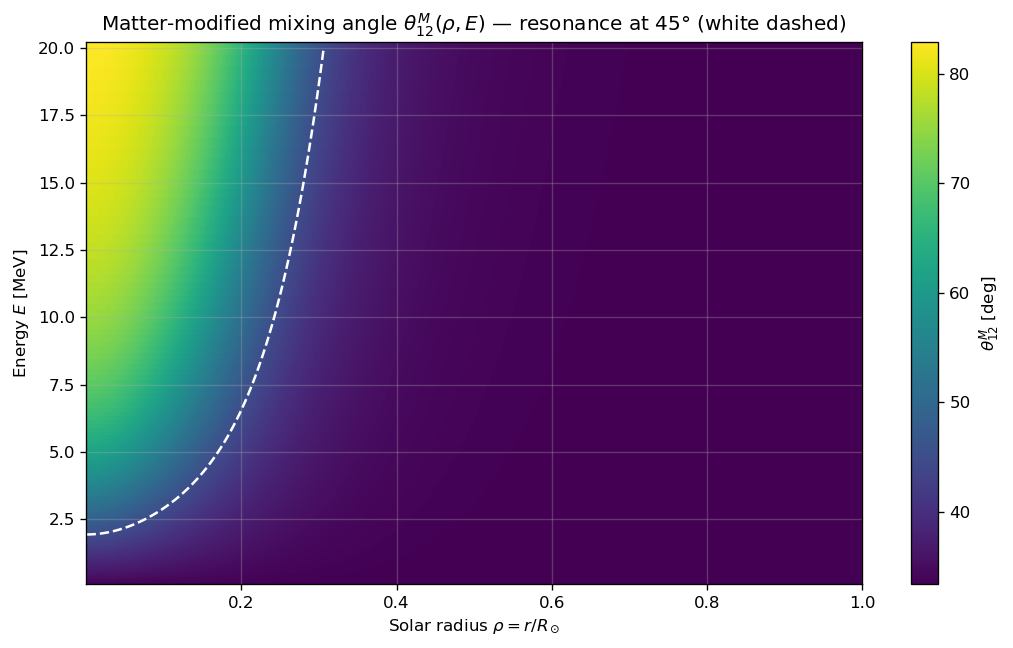

v:\output\analysis\solar\sn2_fig3_th12M_heatmap.png
Vacuum theta12                    : 33.41 deg
theta12_M at core, E=15 MeV      : 82.93 deg
theta12_M at rho=1, E=15 MeV     : 33.41 deg


In [4]:
th12_rad = th12_M(oscillation, ENERGY_GRID_MEV[:, None], NE_GRID)  # (n_E, n_r)
th12_deg = to_numpy(th12_rad) * 180.0 / math.pi

fig, ax = plt.subplots(figsize=(9, 5.5))
mesh = ax.pcolormesh(to_numpy(RHO_GRID), to_numpy(ENERGY_GRID_MEV), th12_deg,
                     shading='auto', cmap='viridis')
cbar = fig.colorbar(mesh, ax=ax, label=r'$\theta_{12}^M$ [deg]')
# Resonance contour at 45 deg
ax.contour(to_numpy(RHO_GRID), to_numpy(ENERGY_GRID_MEV), th12_deg,
           levels=[45.0], colors='white', linewidths=1.5, linestyles='--')
ax.set_xlabel(r'Solar radius $\rho = r/R_\odot$')
ax.set_ylabel('Energy $E$ [MeV]')
ax.set_title(r'Matter-modified mixing angle $\theta_{12}^M(\rho, E)$ — resonance at $45°$ (white dashed)')
fig.tight_layout()
save_and_show('sn2_fig3_th12M_heatmap.png', fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f'Vacuum theta12                    : {THETA12*180/math.pi:.2f} deg')
print(f'theta12_M at core, E=15 MeV      : {th12_deg[-1, 0]:.2f} deg')
print(f'theta12_M at rho=1, E=15 MeV     : {th12_deg[-1, -1]:.2f} deg')

## 4. MSW Resonance Condition — $V_k(\rho)$ Crossing

For each probe energy, $V_k(\rho) = V_k(\Delta m^2_{21}, E, n_e(\rho))$ is plotted against the solar radius. The horizontal dashed line marks $\cos 2\theta_{12}$ (the resonance threshold). The **crossing point** between each curve and the threshold is $r_{\rm res}(E)$.

**Expected results:** 
- at low $E$ ($\leq 0.5$ MeV) the $V_k$ curve stays below the threshold throughout the solar volume — no resonance.
- For $E\geq 2$ MeV the crossing appears and moves outward as $E$ increases, consistent with a resonance density $n_{\rm res}(E)\propto 1/E$.

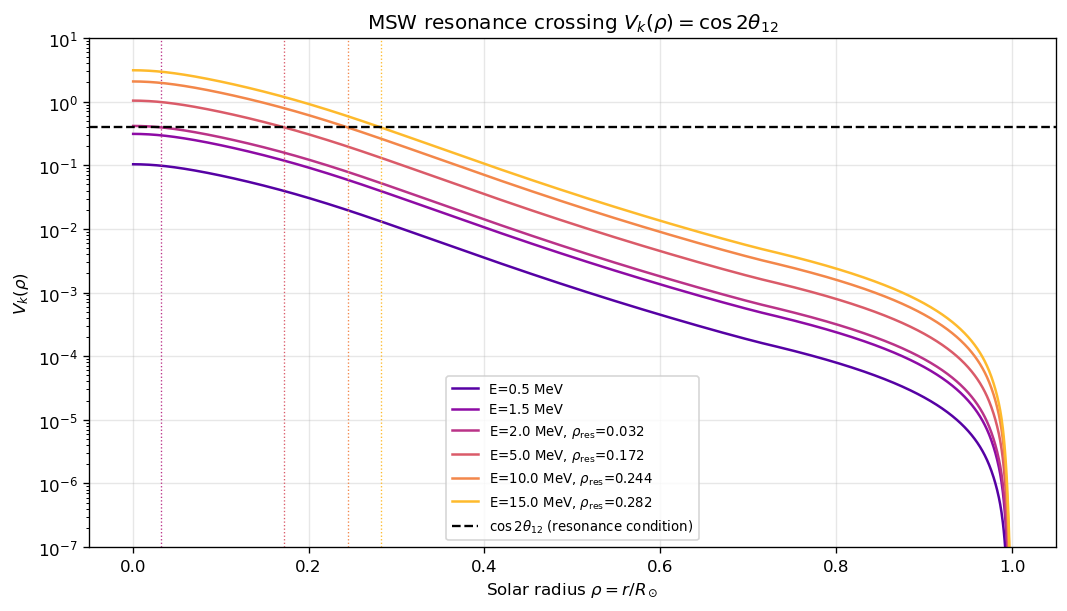

v:\output\analysis\solar\sn2_fig4_vk_crossing.png
cos 2theta12 = 0.39362
  E=  0.5 MeV  no resonance
  E=  1.5 MeV  no resonance
  E=  2.0 MeV  rho_res = 0.0324
  E=  5.0 MeV  rho_res = 0.1724
  E= 10.0 MeV  rho_res = 0.2444
  E= 15.0 MeV  rho_res = 0.2821


In [5]:
target = float(torch.cos(2.0 * pmns.params.theta12))

fig, ax = plt.subplots(figsize=(9, 5.2))
colors = plt.cm.plasma(np.linspace(0.15, 0.85, len(PROBE_ENERGIES)))
for E_val, col in zip(PROBE_ENERGIES, colors):
    vk_curve = Vk(DM21_EV2, torch.tensor(E_val, dtype=ctx.dtype), NE_GRID)
    r_res_val = resonance_radius(oscillation, torch.tensor(E_val, dtype=ctx.dtype), profile)
    label = f'E={E_val:.1f} MeV'
    if torch.isfinite(r_res_val):
        label += rf', $\rho_{{\rm res}}$={float(r_res_val):.3f}'
    ax.plot(to_numpy(RHO_GRID), to_numpy(vk_curve), color=col, label=label)
    if torch.isfinite(r_res_val):
        ax.axvline(float(r_res_val), color=col, lw=0.8, ls=':')

ax.axhline(target, color='black', lw=1.4, ls='--',
           label=r'$\cos 2\theta_{12}$ (resonance condition)')
ax.set_yscale('log')
ax.set_xlabel(r'Solar radius $\rho = r/R_\odot$')
ax.set_ylabel(r'$V_k(\rho)$')
ax.set_title('MSW resonance crossing $V_k(\\rho)=\\cos 2\\theta_{12}$')
ax.set_ylim(1e-7,10)
ax.legend(fontsize=8)
fig.tight_layout()
save_and_show('sn2_fig4_vk_crossing.png', fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f'cos 2theta12 = {target:.5f}')
for E_val in PROBE_ENERGIES:
    r_res_val = resonance_radius(oscillation, torch.tensor(E_val, dtype=ctx.dtype), profile)
    print(f'  E={E_val:5.1f} MeV  rho_res = {float(r_res_val):.4f}' if torch.isfinite(r_res_val) else f'  E={E_val:5.1f} MeV  no resonance')

## 5. Resonance Radius $r_{\rm res}(E)$ per Scenario

The resonance radius as a continuous function of energy is shown for three oscillation scenarios. Colored bands mark the typical energy ranges of solar sources.

| Scenario | $\Delta m^2_{21}$ | Profile used |
|----------|-------------------|--------------|
| **LMA** | $7.41\times10^{-5}$ eV² (NuFIT 5.2) | Standard zenodo SF3-AGSS09 |
| **Hyp** | $\Delta m^2_{21}/100$ | Same extended profile |
| **Non Adiabatic (N.A.)** | $\Delta m^2_{21}/1000$ | Same extended profile |

The hypothetical scenarios are pedagogical only — excluded by solar data by orders of magnitude.

**Expected results:** 
- LMA resonance appears above $\sim 1.5$–2 MeV and stays within $r\lesssim 0.3\,R_\odot$.
- The hypothetical scenarios push the resonance into the outer envelope ($r > 0.5\,R_\odot$), requiring the extended profile.
- The pp band ($E \leq 0.42$ MeV) lies below the LMA threshold: pp neutrinos do **not** cross the MSW resonance and the adiabatic approximation reduces to simple vacuum oscillations for them.

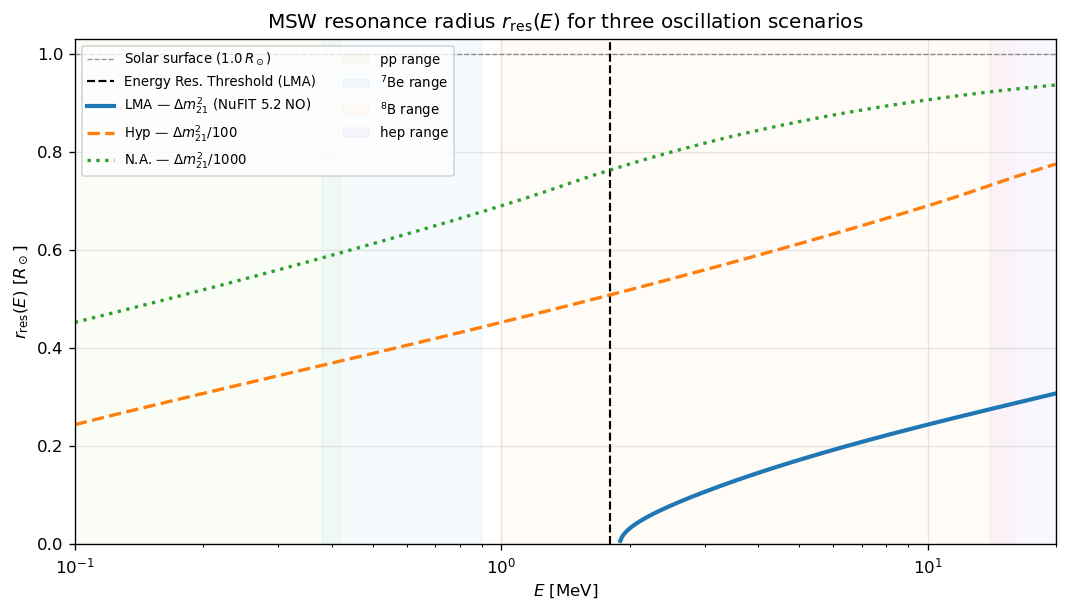

v:\output\analysis\solar\sn2_fig5_resonance_radius.png
Scenario   |  E_thr [MeV] |   r_res(10 MeV)
---------------------------------------------
LMA        |        1.902 |          0.2447
Hyp        |        0.100 |          0.6914
N.A.       |        0.100 |          0.9075


In [6]:
osc_lma      = oscillation
osc_hyp      = dataclasses.replace(osc_lma, DeltamSq21=osc_lma.DeltamSq21 * 0.01)
osc_nonadiab = dataclasses.replace(osc_lma, DeltamSq21=osc_lma.DeltamSq21 * 0.001)

E_scan   = torch.logspace(-1, np.log10(20), 600, dtype=ctx.dtype)
E_scan_np = to_numpy(E_scan)

r_res_lma = to_numpy(resonance_radius(osc_lma,      E_scan, profile))
r_res_hyp = to_numpy(resonance_radius(osc_hyp,      E_scan, profile))
r_res_na  = to_numpy(resonance_radius(osc_nonadiab, E_scan, profile))

valid_all = np.concatenate([r_res_lma[np.isfinite(r_res_lma)],
                             r_res_hyp[np.isfinite(r_res_hyp)],
                             r_res_na[np.isfinite(r_res_na)]])
r_max = valid_all.max() if len(valid_all) else 1.0

fig, ax = plt.subplots(figsize=(9, 5.2))

src_bands = [
    ('pp',          0.10,  0.42, '#CCEE88', 0.55),
    (r'$^7$Be',     0.38,  0.90, '#88CCEE', 0.55),
    (r'$^8$B',      1.00, 16.00, '#FFCC88', 0.45),
    ('hep',        14.00, 20.00, '#CC99EE', 0.55),
]
ax.axhline(1.0, color='black', ls='--', lw=0.8, alpha=0.4, label=r'Solar surface ($1.0\,R_\odot$)')
ax.axvline(1.8, color='black', lw=1.3, ls='--', label=f'Energy Res. Threshold (LMA)')
ax.semilogx(E_scan_np, r_res_lma, color='#1f77b4', lw=2.5,
            label=r'LMA — $\Delta m^2_{21}$ (NuFIT 5.2 NO)')
ax.semilogx(E_scan_np, r_res_hyp, color='#ff7f0e', lw=2.0, ls='--',
            label=r'Hyp — $\Delta m^2_{21}/100$')
ax.semilogx(E_scan_np, r_res_na, color='#2ca02c', lw=2.0, ls=':',
            label=r'N.A. — $\Delta m^2_{21}/1000$')
for lbl, emin, emax, col, alp in src_bands:
    ax.axvspan(emin, emax, alpha=alp*0.15, color=col, label=f'{lbl} range', zorder=0)

ax.set_xlabel('$E$ [MeV]')
ax.set_ylabel(r'$r_{\rm res}(E)$ [$R_\odot$]')
ax.set_title(r'MSW resonance radius $r_{\rm res}(E)$ for three oscillation scenarios')
ax.set_ylim(0, min(1.1*r_max, 1.05))
ax.set_xlim(0.1, 20)

ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
save_and_show('sn2_fig5_resonance_radius.png', fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f'{"Scenario":<10} | {"E_thr [MeV]":>12} | {"r_res(10 MeV)":>15}')
print('-'*45)
for lbl, arr in [("LMA", r_res_lma), ("Hyp", r_res_hyp), ("N.A.", r_res_na)]:
    valid = np.isfinite(arr)
    if valid.any():
        e_thr = E_scan_np[valid][0]
        idx10 = np.argmin(np.abs(E_scan_np - 10.0))
        r10 = arr[idx10] if np.isfinite(arr[idx10]) else float('nan')
        print(f'{lbl:<10} | {e_thr:>12.3f} | {r10:>15.4f}')
    else:
        print(f'{lbl:<10} | no resonance in profile')

## 6. Local Survival Probability $P_{ee}(\rho, E)$

The **pointwise** (non-integrated) survival probability, $P_{ee}(\rho,E)$ is the quantity that, once integrated against a source's production
profile $w_{\rm source}(\rho)$, becomes the `psolar` (Solar Probability)

$$P_{ee}(\rho, E) = \sum_{i=1}^{3}|U_{ei}|^2\,T_{ei}(E,\,n_e(\rho))$$

shows the two limits from Section 0.4 simultaneously. The left panel is a heatmap over the full $( \rho, E)$ plane; the right panel shows 1-D slices at fixed energy.

**Expected results:**
- At low $E$ (quasi-vacuum): $P_{ee}\approx\sum_i|U_{ei}|^4\approx 0.55$ across all radii.
- At high $E$ and small $\rho$ (deep adiabatic): $P_{ee}\to |U_{e2}|^2\approx 0.30$.
- The transition between the two regimes sweeps to larger $\rho$ with increasing $E$, tracing the resonance locus.

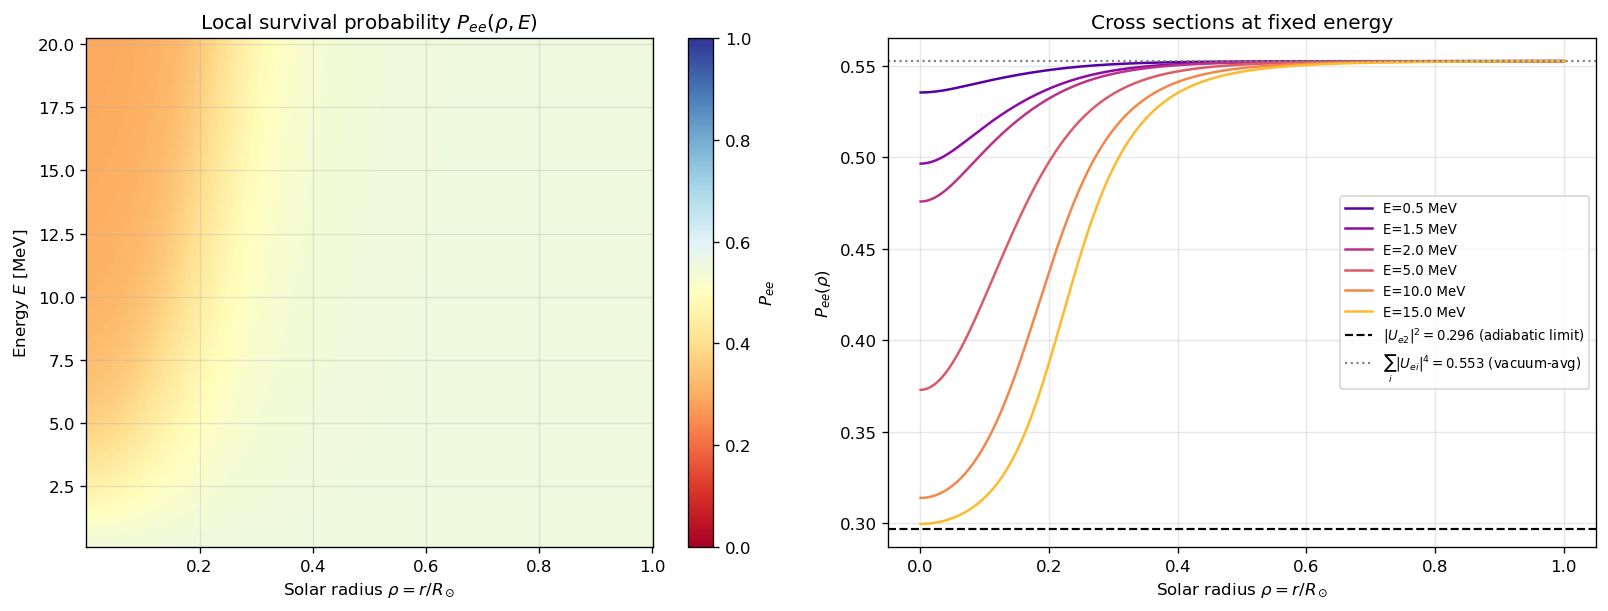

v:\output\analysis\solar\sn2_fig6_local_Pee.png
|U_e2|^2 (deep adiabatic)     = 0.2964
sum |U_ei|^4 (vacuum-averaged) = 0.5525
P_ee at core, E=15 MeV         = 0.2942
P_ee at rho=1, E=0.5 MeV       = 0.5525


In [7]:
def local_pee(E_MeV, ne):
    """Pointwise adiabatic P_ee at (E, n_e) by incoherent sum over Tei weights."""
    weights = Tei(oscillation, E_MeV, ne)                              # (..., 3)
    ident   = torch.eye(3, device=ne.device, dtype=cdtype_from_real(weights.dtype))
    return probability_incoherent(ident, weights, pmns=pmns,
                                  antinu=False, real_dtype=weights.dtype)

Pee_grid = to_numpy(local_pee(ENERGY_GRID_MEV[:, None], NE_GRID)[..., 0])  # (n_E, n_r)

Ue2_sq = float((torch.cos(pmns.params.theta13)**2) * (torch.sin(pmns.params.theta12)**2))
Uei_sq = torch.stack([
    (torch.cos(pmns.params.theta13)**2) * (torch.cos(pmns.params.theta12)**2),
    (torch.cos(pmns.params.theta13)**2) * (torch.sin(pmns.params.theta12)**2),
    (torch.sin(pmns.params.theta13)**2),
])
Pee_vac_avg = float((Uei_sq**2).sum())

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))
mesh = axes[0].pcolormesh(to_numpy(RHO_GRID), to_numpy(ENERGY_GRID_MEV), Pee_grid,
                          shading='auto', cmap='RdYlBu', vmin=0.0, vmax=1.0)
fig.colorbar(mesh, ax=axes[0], label=r'$P_{ee}$')
axes[0].set_xlabel(r'Solar radius $\rho = r/R_\odot$')
axes[0].set_ylabel('Energy $E$ [MeV]')
axes[0].set_title(r'Local survival probability $P_{ee}(\rho, E)$')

colors = plt.cm.plasma(np.linspace(0.15, 0.85, len(PROBE_ENERGIES)))
for E_val, col in zip(PROBE_ENERGIES, colors):
    Pee_slice = to_numpy(local_pee(torch.tensor(E_val, dtype=ctx.dtype), NE_GRID)[..., 0])
    axes[1].plot(to_numpy(RHO_GRID), Pee_slice, color=col, label=f'E={E_val:.1f} MeV')
axes[1].axhline(Ue2_sq,     color='black', lw=1.3, ls='--',
               label=rf'$|U_{{e2}}|^2={Ue2_sq:.3f}$ (adiabatic limit)')
axes[1].axhline(Pee_vac_avg, color='gray',  lw=1.3, ls=':',
               label=rf'$\sum_i|U_{{ei}}|^4={Pee_vac_avg:.3f}$ (vacuum-avg)')
axes[1].set_xlabel(r'Solar radius $\rho = r/R_\odot$')
axes[1].set_ylabel(r'$P_{ee}(\rho)$')
axes[1].set_title('Cross sections at fixed energy')
axes[1].legend(fontsize=8)
fig.tight_layout()
save_and_show('sn2_fig6_local_Pee.png', fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f'|U_e2|^2 (deep adiabatic)     = {Ue2_sq:.4f}')
print(f'sum |U_ei|^4 (vacuum-averaged) = {Pee_vac_avg:.4f}')
print(f'P_ee at core, E=15 MeV         = {Pee_grid[-1, 0]:.4f}')
print(f'P_ee at rho=1, E=0.5 MeV       = {Pee_grid[0, -1]:.4f}')

## 7. Summary

| Quantity | tpeanuts | Validation
|----------|-------|----------|
| Vacuum $\theta_{12}$ | $33.41°$ | NuFIT 5.2 NO |
| $\theta_{12}^M$ at solar core, $E=15$ MeV | $\approx 83°$ (matter-dominated) | |
| LMA resonance threshold $E_{\rm thr}$ | $\approx 1.6$ MeV | |
| $r_{\rm res}$ at $E=15$ MeV (LMA) | $\approx 0.31\,R_\odot$ | |
| Deep-adiabatic $P_{ee}$ asymptote | $|U_{e2}|^2 \approx 0.2964$ | 0.306 (SNO 2009) |
| Quasi-vacuum $P_{ee}$ asymptote | $\sum_i|U_{ei}|^4 \approx 0.5525$ | 0.55 (Borexino 2010) |

**Physical interpretation:**

1. The MSW effect produces an energy-dependent suppression of $P_{ee}$: at high $E$ the neutrino is born in the matter-dominated regime and exits the Sun as nearly pure $\nu_2$, giving $P_{ee}\approx|U_{e2}|^2\approx 0.30$; at low $E$ no resonance is crossed and decoherence gives $P_{ee}\approx\sum_i|U_{ei}|^4\approx 0.55$.
2. The transition occurs in the range $E\approx 1$–$5$ MeV where the resonance radius moves across the solar production region — the very region probed by $^7$Be and $^8$B experiments.
3. The extended zenodo SF3-AGSS09 profile (covering $r\in[0,1]\,R_\odot$) is the default since it correctly represents the density out to the solar surface, which is essential for scenarios whose resonance lies in the outer envelope (see Notebook 2).

**References**
- SNO Collaboration, B. Aharmim et al.,"Low-energy-threshold analysis of the Phase I and Phase II data sets of the Sudbury Neutrino Observatory", Phys. Rev. C 81, 055504 (2010), arXiv:0910.2984.
- Borexino Collaboration, G. Bellini et al.,
"Precision measurement of the 7Be solar neutrino interaction rate in Borexino", Phys. Rev. Lett. 107, 141302 (2011), arXiv:1104.1816.


In [8]:
print('Summary — Solar Neutrino Analysis 2: MSW Resonance')
print('-'*60)
print(f'theta12 (E=15 MeV - vacuum)     : {th12_deg[-1,-1]:.2f} deg')
print(f'theta12 (E=15 MeV - core)       : {th12_deg[-1,0]:.2f} deg')
print(f'theta12 (E=15 MeV - core)       : {th12_deg[-1,0]:.2f} deg')
print(f'r_res (LMA) at E= 15 MeV        : {r_res_lma[-1]:.2f} R_sun')
print(f'|U_e2|^2 (adiabatic asymptote)  : {Ue2_sq:.4f}')
print(f'sum|U_ei|^4 (vacuum asymptote)  : {Pee_vac_avg:.4f}')
print(f'P_ee at solar core, E=15 MeV    : {Pee_grid[-1,0]:.4f}')
print()
for E_val in PROBE_ENERGIES:
    r_v = resonance_radius(osc_lma, torch.tensor(E_val, dtype=ctx.dtype), profile)
    tag = f'{float(r_v):.4f} R_sun' if torch.isfinite(r_v) else 'no resonance'
    print(f'  r_res(E={E_val:5.1f} MeV) = {tag}')

Summary — Solar Neutrino Analysis 2: MSW Resonance
------------------------------------------------------------
theta12 (E=15 MeV - vacuum)     : 33.41 deg
theta12 (E=15 MeV - core)       : 82.93 deg
theta12 (E=15 MeV - core)       : 82.93 deg
r_res (LMA) at E= 15 MeV        : 0.31 R_sun
|U_e2|^2 (adiabatic asymptote)  : 0.2964
sum|U_ei|^4 (vacuum asymptote)  : 0.5525
P_ee at solar core, E=15 MeV    : 0.2942

  r_res(E=  0.5 MeV) = no resonance
  r_res(E=  1.5 MeV) = no resonance
  r_res(E=  2.0 MeV) = 0.0324 R_sun
  r_res(E=  5.0 MeV) = 0.1724 R_sun
  r_res(E= 10.0 MeV) = 0.2444 R_sun
  r_res(E= 15.0 MeV) = 0.2821 R_sun
